<a href="https://colab.research.google.com/github/kxrrym03/FIFA/blob/main/FIFA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test.csv


In [3]:
df = pd.read_csv('test.csv')
df.shape

(48, 24)

In [4]:
df.head()

,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
0,2026,France,Europe,0,85,32,25,6,7,2,...,16,10,8,9,7,4,NaN,NaN,NaN,NaN
1,2026,Spain,Europe,0,104,32,29,2,8,1,...,16,11,9,6,2,1,NaN,NaN,NaN,NaN
2,2026,Argentina,South America,0,80,14,30,4,3,3,...,18,15,10,10,6,6,NaN,NaN,NaN,NaN
3,2026,England,Europe,0,82,23,26,6,7,1,...,16,13,8,10,3,1,NaN,NaN,NaN,NaN
4,2026,Portugal,Europe,0,98,31,26,5,7,0,...,8,5,4,3,2,0,NaN,NaN,NaN,NaN


In [5]:
df.tail()

,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
43,2026,Cape Verde,Africa,0,46,39,16,10,12,0,...,0,0,0,0,0,0,NaN,NaN,NaN,NaN
44,2026,Ghana,Africa,0,46,42,12,13,9,0,...,4,2,2,1,0,0,NaN,NaN,NaN,NaN
45,2026,Cura?o,North America,0,55,39,12,10,10,0,...,0,0,0,0,0,0,NaN,NaN,NaN,NaN
46,2026,Haiti,North America,0,71,37,16,8,8,0,...,1,0,0,0,0,0,NaN,NaN,NaN,NaN
47,2026,New Zealand,Oceania,0,63,32,13,12,6,0,...,2,0,0,0,0,0,NaN,NaN,NaN,NaN


In [6]:
df.isnull().sum()

,0
version,0
team,0
continent,0
is_host,0
goals_scored_last_4y,0
goals_received_last_4y,0
wins_last_4y,0
losses_last_4y,0
draws_last_4y,0
world_cup_titles_before,0


In [7]:
df.drop(['winner', 'finalist', 'semi_finalist', 'quarter_finalist'], axis=1, inplace=True)
print(df.shape)

(48, 20)


In [8]:
df.isnull().sum()

,0
version,0
team,0
continent,0
is_host,0
goals_scored_last_4y,0
goals_received_last_4y,0
wins_last_4y,0
losses_last_4y,0
draws_last_4y,0
world_cup_titles_before,0


In [9]:
for col in df.select_dtypes(include='object').columns:
    print(f'Column {col}: {df[col].nunique()} unique values')
    print(df[col].unique())
    print('\n')

Column team: 48 unique values
['France' 'Spain' 'Argentina' 'England' 'Portugal' 'Brazil' 'Netherlands'
 'Morocco' 'Belgium' 'Germany' 'Croatia' 'Colombia' 'Senegal' 'Mexico'
 'United States' 'Uruguay' 'Japan' 'Switzerland' 'Iran' 'Turkey' 'Ecuador'
 'Austria' 'South Korea' 'Australia' 'Algeria' 'Egypt' 'Canada' 'Norway'
 'Panama' 'Ivory Coast' 'Sweden' 'Paraguay' 'Czech Republic' 'Scotland'
 'Tunisia' 'DR Congo' 'Uzbekistan' 'Qatar' 'Iraq' 'South Africa'
 'Saudi Arabia' 'Jordan' 'Bosnia and Herzegovina' 'Cape Verde' 'Ghana'
 'Cura?o' 'Haiti' 'New Zealand']


Column continent: 6 unique values
['Europe' 'South America' 'Africa' 'North America' 'Asia' 'Oceania']




In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   version                          48 non-null     int64  
 1   team                             48 non-null     object 
 2   continent                        48 non-null     object 
 3   is_host                          48 non-null     int64  
 4   goals_scored_last_4y             48 non-null     int64  
 5   goals_received_last_4y           48 non-null     int64  
 6   wins_last_4y                     48 non-null     int64  
 7   losses_last_4y                   48 non-null     int64  
 8   draws_last_4y                    48 non-null     int64  
 9   world_cup_titles_before          48 non-null     int64  
 10  squad_total_market_value_eur     48 non-null     int64  
 11  fifa_rank_pre_tournament         48 non-null     int64  
 12  fifa_points_pre_tourname

In [12]:
df.describe()

,version,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,squad_total_market_value_eur,fifa_rank_pre_tournament,fifa_points_pre_tournament,squad_avg_age,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before
count,48.0,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,4.800000e+01,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,2026.0,0.062500,72.395833,37.604167,21.354167,8.604167,9.854167,0.375000,3.117183e+08,32.520833,1579.992083,27.206250,7.041667,4.062500,3.020833,2.437500,1.479167,0.708333
std,0.0,0.244623,18.037478,12.316292,5.923231,4.150056,3.614331,1.064415,3.450467e+08,23.819346,156.617330,1.144907,5.946422,5.187572,3.479359,4.078518,2.835861,1.761990
min,2026.0,0.000000,29.000000,14.000000,9.000000,2.000000,3.000000,0.000000,5.300000e+06,1.000000,1281.570000,24.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026.0,0.000000,63.000000,30.000000,17.500000,6.000000,7.000000,0.000000,3.762500e+07,13.750000,1475.097500,26.575000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2026.0,0.000000,72.000000,34.500000,21.500000,8.000000,9.000000,0.000000,1.905750e+08,27.500000,1572.465000,27.100000,6.000000,2.000000,2.000000,0.500000,0.000000,0.000000
75%,2026.0,0.000000,82.250000,42.000000,26.000000,11.250000,12.000000,0.000000,4.372125e+08,47.000000,1690.015000,27.925000,11.000000,7.250000,5.000000,3.000000,2.000000,0.000000
max,2026.0,1.000000,110.000000,70.000000,37.000000,20.000000,20.000000,5.000000,1.300000e+09,85.000000,1877.320000,29.300000,22.000000,20.000000,12.000000,17.000000,13.000000,8.000000


In [13]:
df.dtypes

,0
version,int64
team,object
continent,object
is_host,int64
goals_scored_last_4y,int64
goals_received_last_4y,int64
wins_last_4y,int64
losses_last_4y,int64
draws_last_4y,int64
world_cup_titles_before,int64


In [15]:
avg_fifa_points_by_continent = df.groupby('continent')['fifa_points_pre_tournament'].mean().reset_index()
print("Average FIFA Points by Continent:")
display(avg_fifa_points_by_continent)

Average FIFA Points by Continent:


,continent,fifa_points_pre_tournament
0,Africa,1520.891000
1,Asia,1505.588750
2,Europe,1661.044375
3,North America,1507.773333
4,Oceania,1431.120000
5,South America,1683.401667


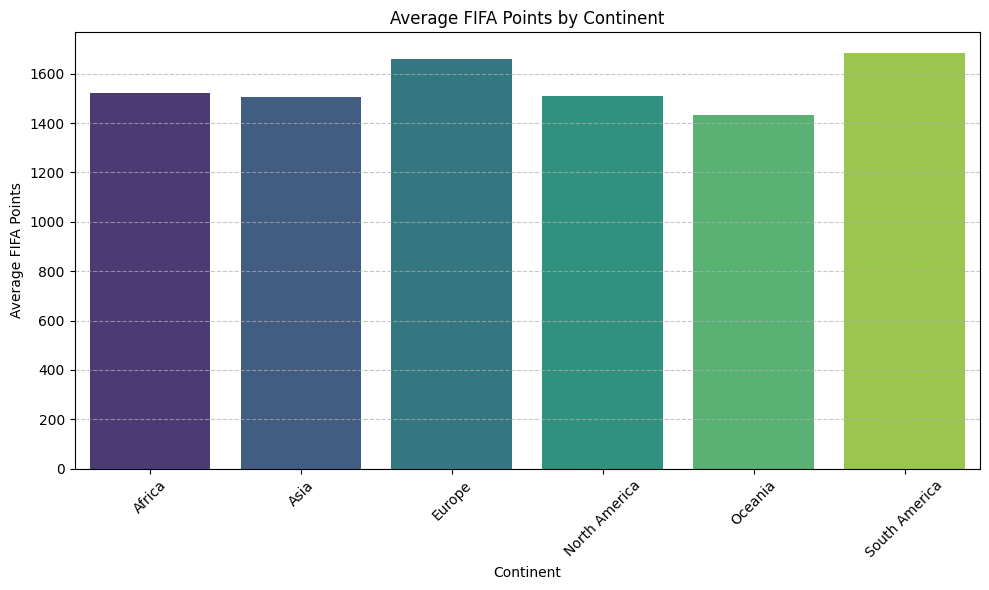

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x='continent', y='fifa_points_pre_tournament', data=avg_fifa_points_by_continent, palette='viridis')
plt.title('Average FIFA Points by Continent')
plt.xlabel('Continent')
plt.ylabel('Average FIFA Points')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

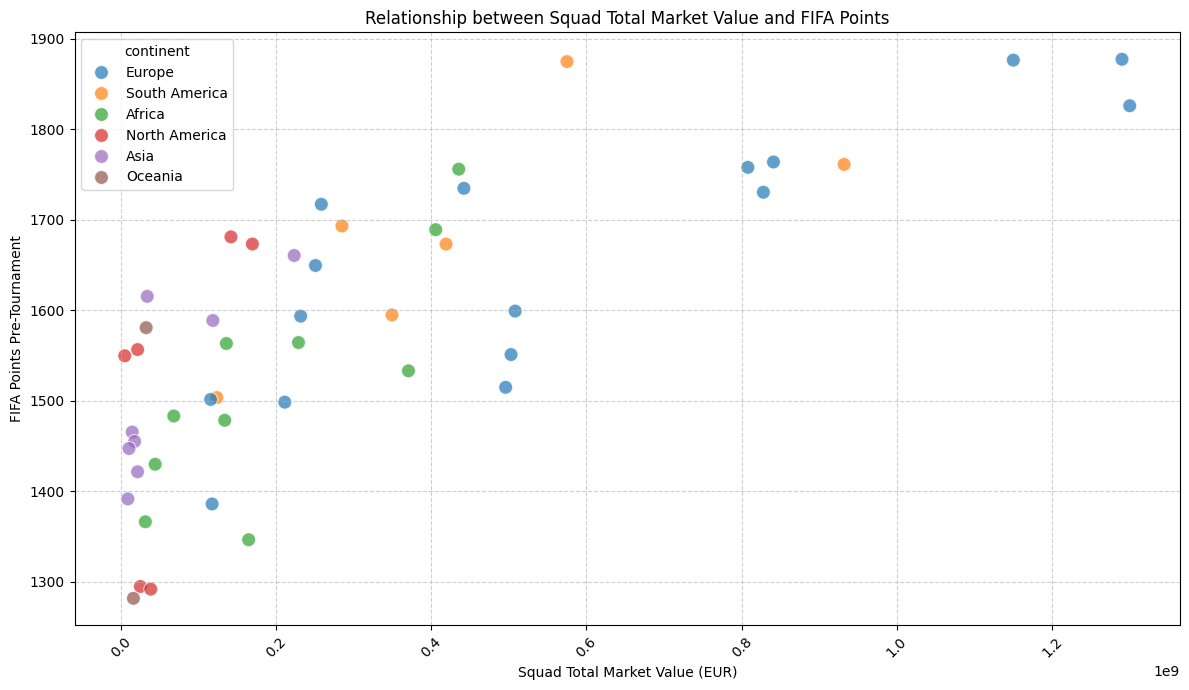

In [17]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='squad_total_market_value_eur', y='fifa_points_pre_tournament', data=df, hue='continent', palette='tab10', s=100, alpha=0.7)
plt.title('Relationship between Squad Total Market Value and FIFA Points')
plt.xlabel('Squad Total Market Value (EUR)')
plt.ylabel('FIFA Points Pre-Tournament')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
avg_fifa_points_by_host = df.groupby('is_host')['fifa_points_pre_tournament'].mean().reset_index()
print("Average FIFA Points by Host Status:")
display(avg_fifa_points_by_host)

Average FIFA Points by Host Status:


,is_host,fifa_points_pre_tournament
0,0,1576.199556
1,1,1636.880000


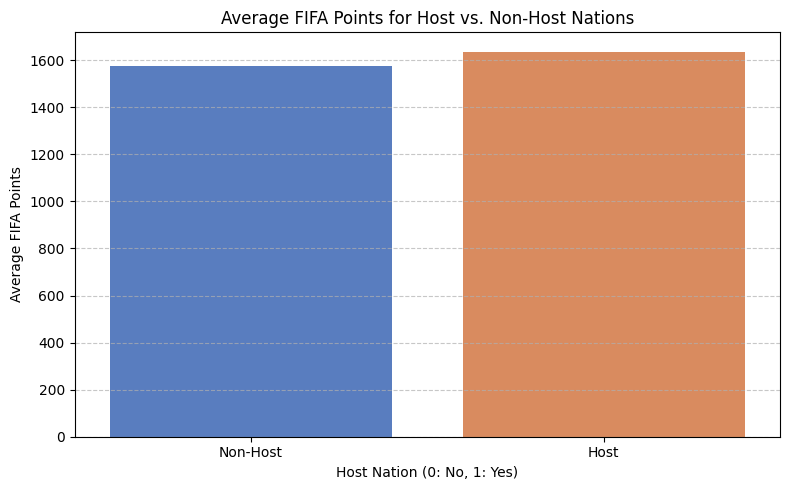

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(x='is_host', y='fifa_points_pre_tournament', data=avg_fifa_points_by_host, palette='muted')
plt.title('Average FIFA Points for Host vs. Non-Host Nations')
plt.xlabel('Host Nation (0: No, 1: Yes)')
plt.ylabel('Average FIFA Points')
plt.xticks(ticks=[0, 1], labels=['Non-Host', 'Host'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

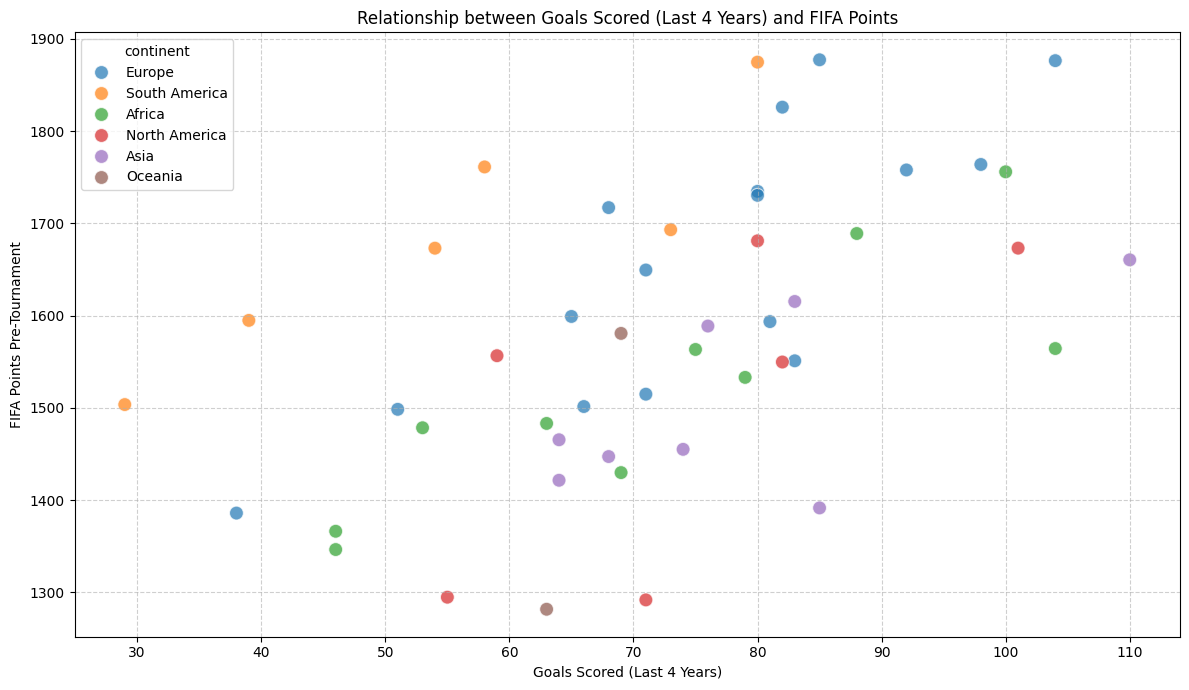

In [20]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='goals_scored_last_4y', y='fifa_points_pre_tournament', data=df, hue='continent', palette='tab10', s=100, alpha=0.7)
plt.title('Relationship between Goals Scored (Last 4 Years) and FIFA Points')
plt.xlabel('Goals Scored (Last 4 Years)')
plt.ylabel('FIFA Points Pre-Tournament')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Feature Engineering and Data Splitting

For supervised machine learning, we need to define our features (`X`) and our target variable (`y`). Since the `df` DataFrame contains data for the 2026 World Cup, it does not yet have an outcome variable (like `winner` or `finalist`), which were dropped earlier due to all null values. Therefore, we'll prepare the features first.

First, we'll perform one-hot encoding on the `continent` categorical column and drop the `team` and `version` columns, as `team` is an identifier and `version` is constant across the dataset.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Drop 'team' and 'version' as they are not features or are constant
X = df.drop(columns=['team', 'version'])

# Identify categorical columns for encoding
# 'continent' is the only categorical column left besides 'team' and 'version'
categorical_features = ['continent']

# Create a column transformer for one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep all other numerical columns
)

# Apply the preprocessing
X_processed = preprocessor.fit_transform(X)

# Get feature names for processed X
onehot_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
other_features = [col for col in X.columns if col not in categorical_features]

# Handle the case where X_processed is a sparse matrix by converting to dense for DataFrame creation
if hasattr(X_processed, 'toarray'):
    X_processed = X_processed.toarray()

# Create a DataFrame for X_processed to inspect it
X_df = pd.DataFrame(X_processed, columns=list(onehot_features) + list(other_features))

print("Shape of processed features (X):")
display(X_df.head())


Shape of processed features (X):


,continent_Africa,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,...,squad_total_market_value_eur,fifa_rank_pre_tournament,fifa_points_pre_tournament,squad_avg_age,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,85.0,32.0,25.0,...,1.290000e+09,1.0,1877.32,26.7,16.0,10.0,8.0,9.0,7.0,4.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,104.0,32.0,29.0,...,1.150000e+09,2.0,1876.40,27.2,16.0,11.0,9.0,6.0,2.0,1.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,80.0,14.0,30.0,...,5.750000e+08,3.0,1874.81,27.9,18.0,15.0,10.0,10.0,6.0,6.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,82.0,23.0,26.0,...,1.300000e+09,4.0,1825.97,26.8,16.0,13.0,8.0,10.0,3.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,98.0,31.0,26.0,...,8.410000e+08,5.0,1763.83,27.1,8.0,5.0,4.0,3.0,2.0,0.0


Now that our features (`X`) are prepared, we need to define the target variable (`y`) for supervised learning. Since the current dataset lacks an explicit target for the 2026 World Cup outcomes, please specify what you would like to predict. For example, if you had historical data with World Cup winners, that would be your `y`.

Once `y` is defined, we can split both `X` and `y` into training and testing sets.

In [22]:
# For demonstration purposes, let's assume we want to predict 'fifa_points_pre_tournament' as a placeholder target 'y'.
# In a real scenario, you would define 'y' based on the actual outcome you want to predict.

# Example placeholder target (remove or replace with your actual target variable):
y = df['fifa_points_pre_tournament']

# Split the data into training and testing sets
# We'll use a test size of 20% and a random state for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

display(X_train.head())


X_train shape: (38, 23)
X_test shape: (10, 23)
y_train shape: (38,)
y_test shape: (10,)


,continent_Africa,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,...,squad_total_market_value_eur,fifa_rank_pre_tournament,fifa_points_pre_tournament,squad_avg_age,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before
8,0.0,0.0,1.0,0.0,0.0,0.0,0.0,80.0,32.0,19.0,...,4.422000e+08,9.0,1734.71,27.1,14.0,9.0,8.0,3.0,2.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,82.0,23.0,26.0,...,1.300000e+09,4.0,1825.97,26.8,16.0,13.0,8.0,10.0,3.0,1.0
6,0.0,0.0,1.0,0.0,0.0,0.0,0.0,92.0,41.0,21.0,...,8.080000e+08,7.0,1757.87,26.6,11.0,11.0,9.0,7.0,5.0,3.0
39,1.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,41.0,20.0,...,4.445000e+07,60.0,1429.73,26.3,3.0,0.0,0.0,0.0,0.0,0.0
33,0.0,0.0,1.0,0.0,0.0,0.0,0.0,51.0,52.0,14.0,...,2.114500e+08,43.0,1498.35,29.1,8.0,0.0,0.0,0.0,0.0,0.0


### Model Training: Random Forest Regressor

We will now train a Random Forest Regressor. This ensemble learning method operates by constructing a multitude of decision trees at training time and outputting the mean prediction (regression) of the individual trees.

In [23]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor model
# We'll use a random_state for reproducibility.
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model on the training data
rf_regressor.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully!")

Random Forest Regressor model trained successfully!


### Model Evaluation: MAE and MSE

Now that our Random Forest Regressor is trained, we need to evaluate its performance on the unseen test data. We'll use two common regression metrics: Mean Absolute Error (MAE) and Mean Squared Error (MSE).

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Make predictions on the test set
y_pred = rf_regressor.predict(X_test)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")

Mean Absolute Error (MAE): 10.16
Mean Squared Error (MSE): 134.89


In [25]:
from sklearn.metrics import r2_score

# Calculate R-squared score
r_squared = r2_score(y_test, y_pred)

print(f"R-squared (R2) score: {r_squared:.2f}")

R-squared (R2) score: 0.99


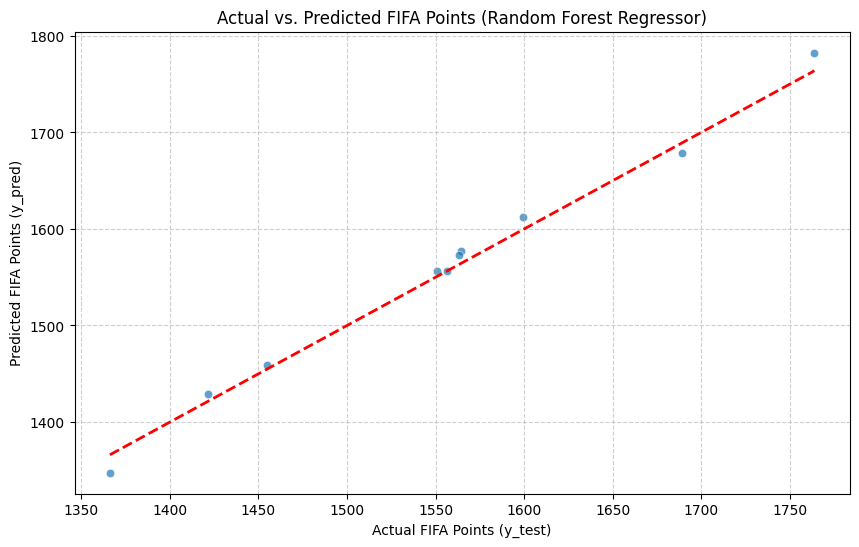

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line for perfect predictions
plt.xlabel('Actual FIFA Points (y_test)')
plt.ylabel('Predicted FIFA Points (y_pred)')
plt.title('Actual vs. Predicted FIFA Points (Random Forest Regressor)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()